
# Lab-8

**Name:** Abdul Qudoos 
**CMS:** 023-24-0233  
**Section:** G  
**GitHub Profile:**(https://github.com/abdulqudoos181005)
**Kaggle Profile:** https://www.kaggle.com/abdulqudoos7860 
 



# Part 0 — Recap and Setup

## Objective
Prepare the Telco Customer Churn dataset using the same cleaning/encoding approach from the previous labs.

Required steps:
1. Convert `TotalCharges` to numeric.
2. Handle missing values.
3. Drop `customerID`.
4. Map `Churn` to 0/1.
5. One-hot encode categorical columns.
6. Split into train/test data using `stratify=y`.

In [1]:
# =========================
# PART 0 — SETUP
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)
from sklearn.decomposition import PCA

warnings.filterwarnings("ignore")

# Change this filename if your CSV has a different name.
DATA_PATH = "WA_Fn-UseC_-Telco-Customer-Churn.csv"

# Keep these identical to your previous labs.
TEST_SIZE = 0.20
RANDOM_STATE = 42

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
# Inspect dataset
print(df.info())
print("\nMissing values:")
display(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [3]:
# Convert TotalCharges to numeric.
# Invalid/blank values become NaN.
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

# Handle missing TotalCharges using the median.
df["TotalCharges"] = df["TotalCharges"].fillna(
    df["TotalCharges"].median()
)

# Drop customerID because it is an identifier, not a useful predictive feature.
df = df.drop("customerID", axis=1)

# Map target variable to 0/1.
df["Churn"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

# One-hot encode categorical features.
categorical_columns = df.select_dtypes(include="object").columns

df = pd.get_dummies(
    df,
    columns=categorical_columns,
    drop_first=True
)

print("Cleaned dataset shape:", df.shape)
display(df.head())

Cleaned dataset shape: (7043, 31)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


In [4]:
# Separate features and target
X = df.drop("Churn", axis=1)
y = df["Churn"]

# Train/test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training shape:", X_train.shape)
print("Testing shape :", X_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting class distribution:")
print(y_test.value_counts(normalize=True))

Training shape: (5634, 30)
Testing shape : (1409, 30)

Training class distribution:
Churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64

Testing class distribution:
Churn
0    0.734564
1    0.265436
Name: proportion, dtype: float64


# Part 1 — Why Scaling Matters for SVM

## Task 1.1

Train:
1. A linear SVM on the **unscaled** features.
2. A linear SVM on the **scaled** features.

Compare:
- Accuracy
- Precision
- Recall
- F1-score
- Training time
- Any convergence warnings

### Questions
1. What differences did you observe between the unscaled and scaled models?
2. Why does an unscaled linear SVM behave this way in terms of the margin/decision boundary?
3. From this point onward, which version will you use and why?

In [5]:
# =========================
# PART 1 — UNscaled SVM
# =========================

start = time.time()

svm_raw = SVC(
    kernel="linear",
    random_state=RANDOM_STATE
)

svm_raw.fit(X_train, y_train)

raw_time = time.time() - start
y_pred_raw = svm_raw.predict(X_test)

raw_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_raw),
    "Precision": precision_score(y_test, y_pred_raw, zero_division=0),
    "Recall": recall_score(y_test, y_pred_raw, zero_division=0),
    "F1-score": f1_score(y_test, y_pred_raw, zero_division=0),
    "Training Time (s)": raw_time
}

print("Unscaled Linear SVM")
for key, value in raw_metrics.items():
    print(f"{key}: {value:.4f}")

Unscaled Linear SVM
Accuracy: 0.7906
Precision: 0.6639
Recall: 0.4278
F1-score: 0.5203
Training Time (s): 838.2819


In [6]:
# =========================
# PART 1 — SCALING
# =========================

# IMPORTANT:
# Fit the scaler ONLY on the training data.
scaler = StandardScaler()

X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print("Scaling completed.")
print("Training shape:", X_train_s.shape)
print("Testing shape :", X_test_s.shape)

Scaling completed.
Training shape: (5634, 30)
Testing shape : (1409, 30)


In [7]:
# =========================
# PART 1 — SCALED SVM
# =========================

start = time.time()

svm_scaled = SVC(
    kernel="linear",
    random_state=RANDOM_STATE
)

svm_scaled.fit(X_train_s, y_train)

scaled_time = time.time() - start
y_pred_scaled = svm_scaled.predict(X_test_s)

scaled_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_scaled),
    "Precision": precision_score(y_test, y_pred_scaled, zero_division=0),
    "Recall": recall_score(y_test, y_pred_scaled, zero_division=0),
    "F1-score": f1_score(y_test, y_pred_scaled, zero_division=0),
    "Training Time (s)": scaled_time
}

print("Scaled Linear SVM")
for key, value in scaled_metrics.items():
    print(f"{key}: {value:.4f}")

Scaled Linear SVM
Accuracy: 0.7892
Precision: 0.6207
Recall: 0.5294
F1-score: 0.5714
Training Time (s): 3.4565


In [8]:
# Scaling comparison table

scaling_comparison = pd.DataFrame([
    {"Model": "Unscaled Linear SVM", **raw_metrics},
    {"Model": "Scaled Linear SVM", **scaled_metrics}
])

display(scaling_comparison)

,Model,Accuracy,Precision,Recall,F1-score,Training Time (s)
0,Unscaled Linear SVM,0.790632,0.66390,0.427807,0.520325,838.281934
1,Scaled Linear SVM,0.789212,0.62069,0.529412,0.571429,3.456450


### Part 1 — Interpretation

**(a) Observed differences:**  
Fill this answer using the actual values in the table above.

**(b) Why scaling matters:**  
SVM uses a geometric margin and distance-based calculations. Features with much larger numerical ranges can dominate these calculations when features are not scaled. StandardScaler puts the features on comparable scales, allowing the SVM to construct its boundary more consistently.

**(c) Version used from now on:**  
Use the **scaled features** for the remaining SVM experiments because SVM is sensitive to feature scale.

> Replace/add details above using your own measured accuracy, F1-score, training time, and warnings.

# Part 2 — Kernel Comparison

## Task 2.1

Train and fairly compare:
- Linear kernel
- RBF kernel
- Polynomial kernel

All models must use the **same scaled train/test split**.

Record:
- Accuracy
- Precision
- Recall
- F1-score
- Number of support vectors

Then plot a confusion matrix for the kernel with the highest F1-score.

In [9]:
# =========================
# PART 2 — KERNEL COMPARISON
# =========================

kernels = ["linear", "rbf", "poly"]
kernel_results = []
kernel_models = {}

for kernel in kernels:
    model = SVC(
        kernel=kernel,
        random_state=RANDOM_STATE
    )

    start = time.time()
    model.fit(X_train_s, y_train)
    training_time = time.time() - start

    y_pred = model.predict(X_test_s)

    kernel_models[kernel] = model

    kernel_results.append({
        "Kernel": kernel,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-score": f1_score(y_test, y_pred, zero_division=0),
        "Support Vectors": model.support_.shape[0],
        "Training Time (s)": training_time
    })

kernel_results_df = pd.DataFrame(kernel_results)

display(kernel_results_df)

,Kernel,Accuracy,Precision,Recall,F1-score,Support Vectors,Training Time (s)
0,linear,0.789212,0.620690,0.529412,0.571429,2569,3.389951
1,rbf,0.792761,0.644366,0.489305,0.556231,2661,2.438836
2,poly,0.789212,0.642066,0.465241,0.539535,2739,1.994806


In [10]:
# Identify the kernel with the best F1-score
best_kernel_row = kernel_results_df.loc[
    kernel_results_df["F1-score"].idxmax()
]

best_kernel_name = best_kernel_row["Kernel"]

print("Best kernel by test F1-score:", best_kernel_name)
print("Best F1-score:", best_kernel_row["F1-score"])

Best kernel by test F1-score: linear
Best F1-score: 0.5714285714285714


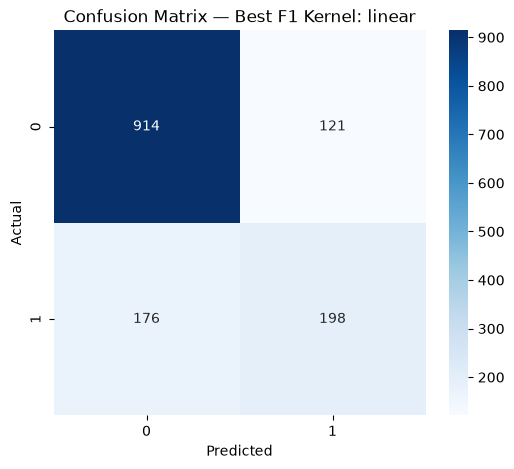

In [11]:
# Confusion matrix for the best-F1 kernel

best_kernel_model = kernel_models[best_kernel_name]
best_kernel_pred = best_kernel_model.predict(X_test_s)

cm = confusion_matrix(y_test, best_kernel_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix — Best F1 Kernel: {best_kernel_name}")
plt.show()

### Part 2 — Interpretation

**(a) Best F1 kernel:**  
The kernel with the highest measured test F1-score is shown above. Explain why this result does or does not match your SVM theory.

**(b) Support vectors:**  
The kernel with the largest support-vector count can be identified from the comparison table. A high support-vector count means many training observations participate in defining the decision boundary.

**(c) Kernel carried forward:**  
For Part 4, the lab specifically asks for an RBF-kernel SVM. Use the RBF model as the model being tuned there, while referring to your Part 2 results when explaining the kernel choice.

> Replace this section with your own numerical interpretation.

# Part 3 — Visualizing the Margin: What Does C Actually Do?

## Task 3.1

The real dataset has many features, so its full decision boundary cannot be directly plotted. We will use PCA to project the **scaled training data** into two dimensions.

Then we will train RBF SVMs using:
- `C = 0.01`
- `C = 1`
- `C = 100`

and visualize their approximate decision regions.

**Important:** This is a 2-D projection for intuition. It is not the actual full-dimensional SVM boundary.

In [12]:
# =========================
# PART 3 — PCA
# =========================

pca = PCA(n_components=2)

X_train_pca = pca.fit_transform(X_train_s)

explained_variance = pca.explained_variance_ratio_
total_explained_variance = explained_variance.sum()

print("Explained variance ratio:")
print(explained_variance)

print(f"Total explained variance: {total_explained_variance:.4f}")
print(f"Percentage shown in 2-D: {total_explained_variance * 100:.2f}%")

Explained variance ratio:
[0.33246151 0.11980321]
Total explained variance: 0.4523
Percentage shown in 2-D: 45.23%


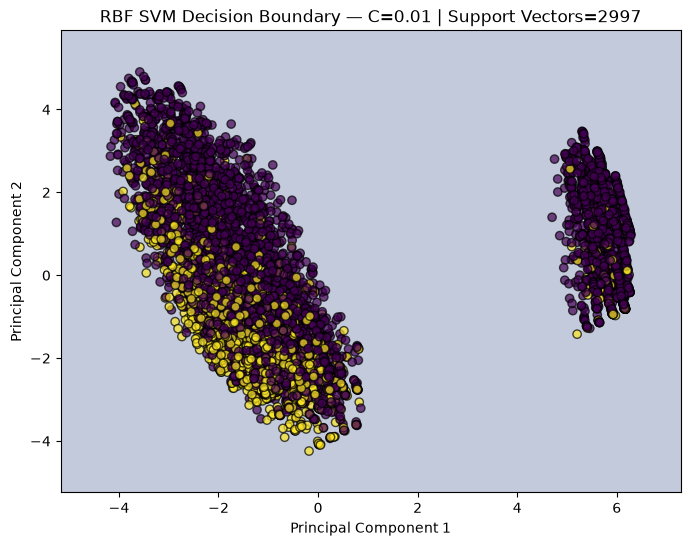

C = 0.01 | Support Vectors = 2997


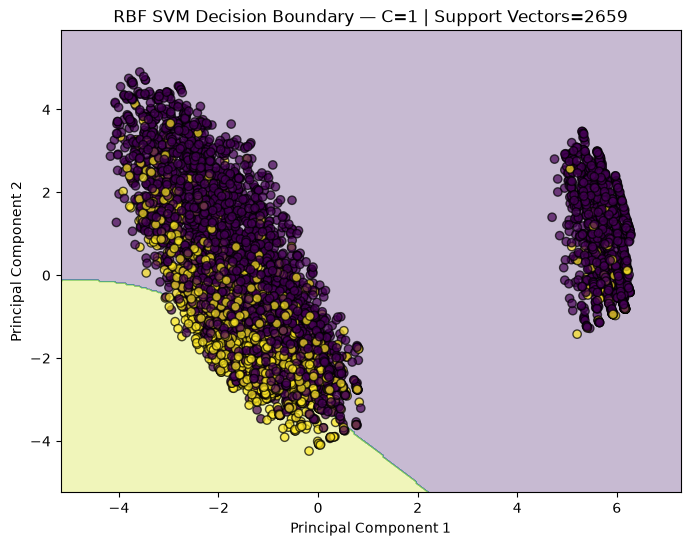

C = 1 | Support Vectors = 2659


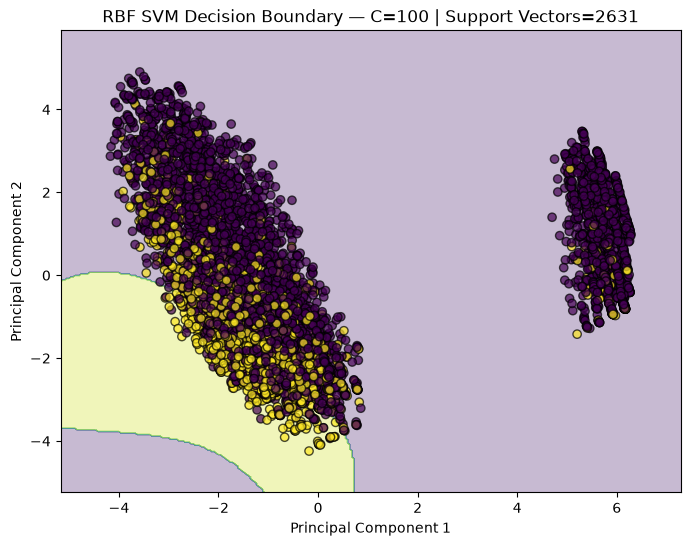

C = 100 | Support Vectors = 2631


In [13]:
# =========================
# PART 3 — C EXPERIMENT
# =========================

C_values = [0.01, 1, 100]
C_support_vectors = {}

for C_value in C_values:

    model = SVC(
        kernel="rbf",
        C=C_value,
        random_state=RANDOM_STATE
    )

    model.fit(X_train_pca, y_train)

    C_support_vectors[C_value] = model.support_.shape[0]

    # Mesh grid
    x_min = X_train_pca[:, 0].min() - 1
    x_max = X_train_pca[:, 0].max() + 1

    y_min = X_train_pca[:, 1].min() - 1
    y_max = X_train_pca[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    grid = np.c_[
        xx.ravel(),
        yy.ravel()
    ]

    Z = model.predict(grid).reshape(xx.shape)

    plt.figure(figsize=(8, 6))

    plt.contourf(
        xx,
        yy,
        Z,
        alpha=0.30
    )

    plt.scatter(
        X_train_pca[:, 0],
        X_train_pca[:, 1],
        c=y_train,
        edgecolors="k",
        alpha=0.70
    )

    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.title(
        f"RBF SVM Decision Boundary — C={C_value} | "
        f"Support Vectors={model.support_.shape[0]}"
    )

    plt.show()

    print(
        f"C = {C_value} | "
        f"Support Vectors = {model.support_.shape[0]}"
    )

### Part 3 — Interpretation

Answer using your three actual plots and support-vector counts.

**(a) Boundary change as C increases:**  
Describe whether the boundary became smoother, tighter, or more complex.

**(b) Support vectors:**  
Report the support-vector count for each C and compare it with your theoretical expectation.

**(c) Overfitting / underfitting:**  
Identify which plot appears relatively simple and which appears relatively complex. Explain the visual evidence rather than assuming that the largest C must always overfit.

**(d) Why is the plot approximate?**  
The original SVM operates in the full feature space. PCA compresses that space into only two components. Information represented by the remaining components is not directly visible, so the 2-D plot can simplify or hide relationships present in the actual model.

# Part 4 — Systematic Hyperparameter Search

## Task 4.1

Use `GridSearchCV` on the **full scaled feature set**, not the PCA projection.

Search over:
- multiple values of `C`
- multiple values of `gamma`

Use:
- RBF SVM
- 5-fold cross-validation
- F1-score as the selection metric

Then:
1. Inspect the full CV results.
2. Create a C × gamma heatmap.
3. Evaluate the best estimator on the held-out test set.

In [14]:
# =========================
# PART 4 — GRID SEARCH
# =========================

param_grid = {
    "C": [0.1, 1, 10, 100],
    "gamma": [0.001, 0.01, 0.1, 1]
}

rbf_svm = SVC(
    kernel="rbf",
    random_state=RANDOM_STATE
)

grid_search = GridSearchCV(
    estimator=rbf_svm,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    return_train_score=True
)

start = time.time()

grid_search.fit(
    X_train_s,
    y_train
)

grid_time = time.time() - start

print(f"Grid search time: {grid_time:.2f} seconds")
print("Best parameters:", grid_search.best_params_)
print("Best CV F1-score:", grid_search.best_score_)

Grid search time: 99.41 seconds
Best parameters: {'C': 100, 'gamma': 0.01}
Best CV F1-score: 0.5876873460047569


In [15]:
# Full GridSearchCV results

cv_results_df = pd.DataFrame(grid_search.cv_results_)

display(
    cv_results_df[
        [
            "param_C",
            "param_gamma",
            "mean_test_score",
            "std_test_score",
            "rank_test_score"
        ]
    ].sort_values("rank_test_score")
)

,param_C,param_gamma,mean_test_score,std_test_score,rank_test_score
13,100.0,0.010,0.587687,0.022004,1
8,10.0,0.001,0.585666,0.031513,2
9,10.0,0.010,0.585282,0.025348,3
4,1.0,0.001,0.574639,0.023163,4
6,1.0,0.100,0.573405,0.026669,5
12,100.0,0.001,0.570981,0.032070,6
5,1.0,0.010,0.565038,0.033742,7
1,0.1,0.010,0.541689,0.031503,8
10,10.0,0.100,0.526574,0.020165,9
14,100.0,0.100,0.505957,0.021643,10


param_C,0.1,1.0,10.0,100.0
param_gamma,,,,
0.001,0.000000,0.574639,0.585666,0.570981
0.010,0.541689,0.565038,0.585282,0.587687
0.100,0.463951,0.573405,0.526574,0.505957
1.000,0.000000,0.326124,0.362099,0.362108


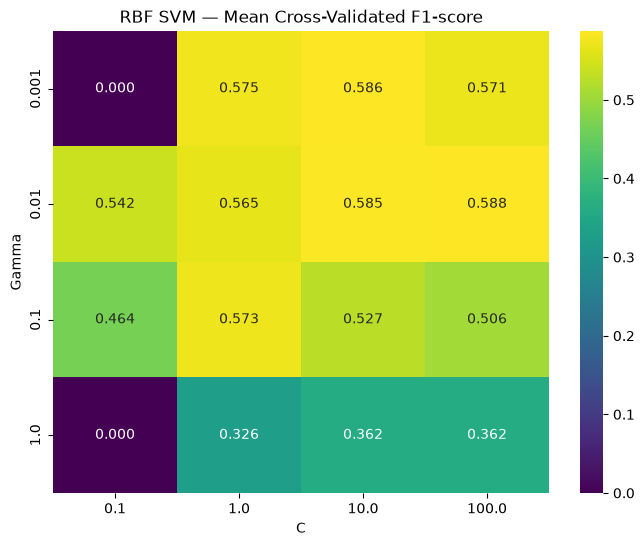

In [16]:
# =========================
# PART 4 — HEATMAP
# =========================

heatmap_data = cv_results_df.pivot(
    index="param_gamma",
    columns="param_C",
    values="mean_test_score"
)

display(heatmap_data)

plt.figure(figsize=(8, 6))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".3f",
    cmap="viridis"
)

plt.title("RBF SVM — Mean Cross-Validated F1-score")
plt.xlabel("C")
plt.ylabel("Gamma")
plt.show()

In [17]:
# =========================
# PART 4 — TEST PERFORMANCE
# =========================

best_svm = grid_search.best_estimator_

y_pred_tuned = best_svm.predict(X_test_s)

tuned_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_tuned),
    "Precision": precision_score(y_test, y_pred_tuned, zero_division=0),
    "Recall": recall_score(y_test, y_pred_tuned, zero_division=0),
    "F1-score": f1_score(y_test, y_pred_tuned, zero_division=0)
}

print("Tuned RBF SVM — Test Set")
for key, value in tuned_metrics.items():
    print(f"{key}: {value:.4f}")

Tuned RBF SVM — Test Set
Accuracy: 0.7786
Precision: 0.5939
Recall: 0.5241
F1-score: 0.5568


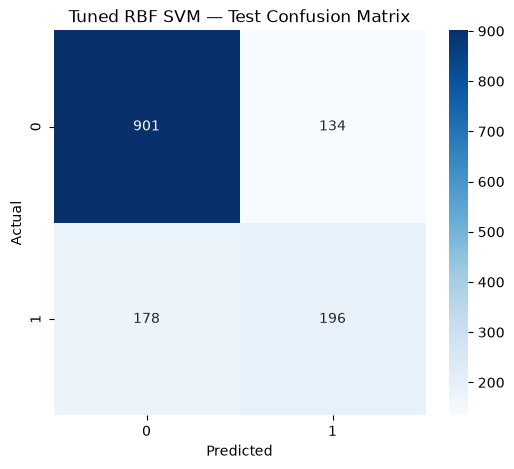

In [18]:
# Tuned RBF confusion matrix

cm_tuned = confusion_matrix(
    y_test,
    y_pred_tuned
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_tuned,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Tuned RBF SVM — Test Confusion Matrix")
plt.show()

### Part 4 — Interpretation

**(a) Best parameters:**  
- Best C = `100`
- Best gamma = `0.01`
- Best cross-validated F1 = `0.588`

**(b) Heatmap:**  
Describe whether there is a clear high-performing region or several combinations with similar F1-scores.

**(c) CV vs test:**  
Compare the best cross-validated F1-score with the held-out test F1-score. A large gap can indicate that the cross-validation estimate does not transfer as closely to the held-out test set.

**(d) Tuning value:**  
Compare the tuned RBF test F1-score with the untuned RBF test F1-score from Part 2. State the numerical difference and discuss whether the extra computation produced a meaningful change.

# Part 5 — Class Imbalance and the Business Trade-off

## Task 5.1

Using the best `C` and `gamma` from Part 4, compare:
1. `class_weight=None`
2. `class_weight="balanced"`

Report:
- Precision
- Recall
- F1-score
- Confusion matrix

Then produce an ROC curve for the balanced model.

**Business context:** Churners are a minority class. Accuracy alone can therefore hide poor detection of actual churners.

In [19]:
# =========================
# PART 5 — DEFAULT VS BALANCED
# =========================

best_C = grid_search.best_params_["C"]
best_gamma = grid_search.best_params_["gamma"]

print("Using:")
print("C =", best_C)
print("gamma =", best_gamma)

Using:
C = 100
gamma = 0.01


In [20]:
# Default class weights

svm_default = SVC(
    kernel="rbf",
    C=best_C,
    gamma=best_gamma,
    class_weight=None,
    random_state=RANDOM_STATE
)

svm_default.fit(X_train_s, y_train)

pred_default = svm_default.predict(X_test_s)


# Balanced class weights

svm_balanced = SVC(
    kernel="rbf",
    C=best_C,
    gamma=best_gamma,
    class_weight="balanced",
    random_state=RANDOM_STATE
)

svm_balanced.fit(X_train_s, y_train)

pred_balanced = svm_balanced.predict(X_test_s)

In [21]:
# Comparison table

imbalance_results = pd.DataFrame([
    {
        "Model": "Default",
        "Precision": precision_score(y_test, pred_default, zero_division=0),
        "Recall": recall_score(y_test, pred_default, zero_division=0),
        "F1-score": f1_score(y_test, pred_default, zero_division=0)
    },
    {
        "Model": "Balanced",
        "Precision": precision_score(y_test, pred_balanced, zero_division=0),
        "Recall": recall_score(y_test, pred_balanced, zero_division=0),
        "F1-score": f1_score(y_test, pred_balanced, zero_division=0)
    }
])

display(imbalance_results)

,Model,Precision,Recall,F1-score
0,Default,0.593939,0.524064,0.556818
1,Balanced,0.515206,0.770053,0.617363


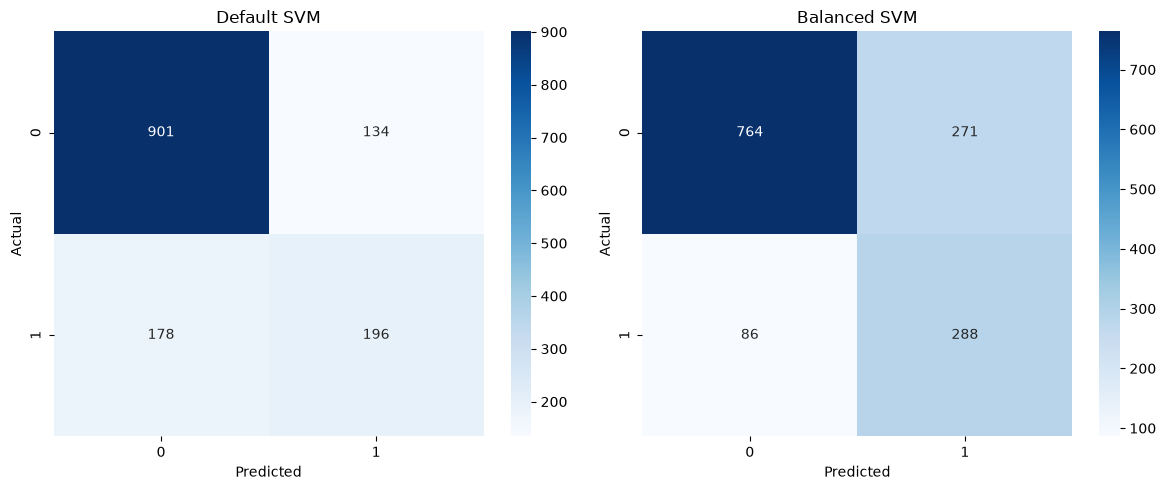

In [22]:
# Confusion matrices

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_default = confusion_matrix(y_test, pred_default)
cm_balanced = confusion_matrix(y_test, pred_balanced)

sns.heatmap(
    cm_default,
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=axes[0]
)

axes[0].set_title("Default SVM")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(
    cm_balanced,
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=axes[1]
)

axes[1].set_title("Balanced SVM")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

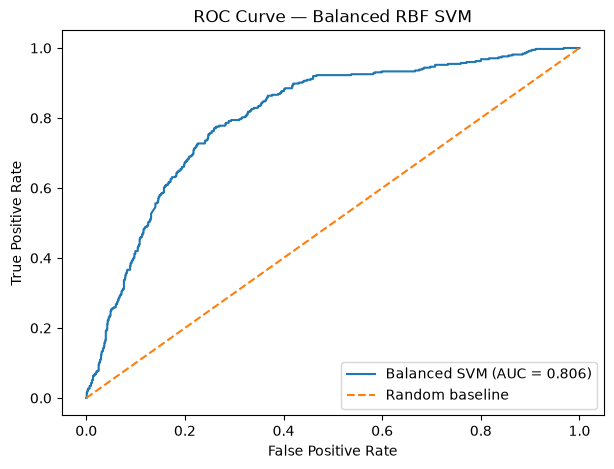

ROC AUC: 0.8057932263814618


In [23]:
# =========================
# PART 5 — ROC CURVE
# =========================

# SVC needs probability=True if we want predict_proba().
# This adds extra fitting overhead.

svm_balanced_prob = SVC(
    kernel="rbf",
    C=best_C,
    gamma=best_gamma,
    class_weight="balanced",
    probability=True,
    random_state=RANDOM_STATE
)

svm_balanced_prob.fit(
    X_train_s,
    y_train
)

y_prob_balanced = svm_balanced_prob.predict_proba(
    X_test_s
)[:, 1]

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob_balanced
)

roc_auc = roc_auc_score(
    y_test,
    y_prob_balanced
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Balanced SVM (AUC = {roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random baseline"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Balanced RBF SVM")
plt.legend()
plt.show()

print("ROC AUC:", roc_auc)

### Part 5 — Interpretation

**(a) Precision and recall movement:**  
Copy the exact values from the comparison table and describe how they changed when `class_weight="balanced"` was used.

**(b) Business trade-off:**  
A false negative means an actual churner was missed. A false positive means a customer was flagged as at-risk even though they did not churn. Discuss which error would be more costly for the telecom business under the assumptions you choose, then connect that reasoning to the measured precision and recall of the two models.

**(c) Probability-like scores:**  
SVC does not directly provide probabilities by default. `probability=True` must be enabled to use `predict_proba()`. The resulting values can then be used for ROC/PR analysis.

# Part 6 — Model Showdown: SVM vs. Everything Else

## Task 6.1

Compare these five algorithms on the **same test set**:
- Decision Tree
- Random Forest
- Logistic Regression
- KNN
- Best SVM

Required metrics:
- Accuracy
- Precision
- Recall
- F1-score

If you have exact results from previous labs, you may enter them below. If not, the optional rerun cells can train the four previous models using this lab's same train/test split.

## Option A — Enter Previous Lab Results

If you already saved your exact results from Labs 3, 4, and 6, enter them in this table. This is preferable when your previous labs used a specific tuned configuration.

In [24]:
# Enter your previous-lab metrics here if you already have them.
# Replace None with your actual values.

previous_results = pd.DataFrame([
    {
        "Model": "Decision Tree",
        "Accuracy": None,
        "Precision": None,
        "Recall": None,
        "F1-score": None
    },
    {
        "Model": "Random Forest",
        "Accuracy": None,
        "Precision": None,
        "Recall": None,
        "F1-score": None
    },
    {
        "Model": "Logistic Regression",
        "Accuracy": None,
        "Precision": None,
        "Recall": None,
        "F1-score": None
    },
    {
        "Model": "KNN",
        "Accuracy": None,
        "Precision": None,
        "Recall": None,
        "F1-score": None
    }
])

display(previous_results)

,Model,Accuracy,Precision,Recall,F1-score
0,Decision Tree,None,None,None,None
1,Random Forest,None,None,None,None
2,Logistic Regression,None,None,None,None
3,KNN,None,None,None,None


## Option B — Rerun Previous Models

Use the following optional cells if you did not save the exact previous results. The comparison is then performed using this lab's same split.

The manual says that re-running the previous models is acceptable when exact numbers were not saved.

In [25]:
# Optional rerun: Decision Tree, Random Forest, Logistic Regression, KNN

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

# Decision Tree
dt_model = DecisionTreeClassifier(
    random_state=RANDOM_STATE
)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)

# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=RANDOM_STATE
)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

# Logistic Regression
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE
)
lr_model.fit(X_train_s, y_train)
lr_pred = lr_model.predict(X_test_s)

# KNN
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(
    n_neighbors=5
)
knn_model.fit(X_train_s, y_train)
knn_pred = knn_model.predict(X_test_s)

print("Optional previous-model reruns completed.")

Optional previous-model reruns completed.


### Choose Which Previous Results to Use

If you used **Option A**, use your previous-lab results.

If you used **Option B**, run the next cell and use the rerun predictions.

For the SVM row, the cell below uses the **tuned default-weight RBF SVM**. If your final deployment choice is the balanced model, replace `svm_final_pred` with the balanced model's predictions.

In [26]:
# =========================
# PART 6 — BUILD SCOREBOARD
# =========================

# Set this to True if you want to use the optional rerun predictions.
USE_RERUN_PREVIOUS_MODELS = True

if USE_RERUN_PREVIOUS_MODELS:

    previous_predictions = {
        "Decision Tree": dt_pred,
        "Random Forest": rf_pred,
        "Logistic Regression": lr_pred,
        "KNN": knn_pred
    }

    previous_rows = []

    for name, pred in previous_predictions.items():
        previous_rows.append({
            "Model": name,
            "Accuracy": accuracy_score(y_test, pred),
            "Precision": precision_score(y_test, pred, zero_division=0),
            "Recall": recall_score(y_test, pred, zero_division=0),
            "F1-score": f1_score(y_test, pred, zero_division=0)
        })

    previous_results_final = pd.DataFrame(previous_rows)

else:
    previous_results_final = previous_results.copy()


# SVM used for the scoreboard.
# Default tuned RBF is used here.
svm_final_pred = pred_default

svm_row = pd.DataFrame([{
    "Model": "SVM",
    "Accuracy": accuracy_score(y_test, svm_final_pred),
    "Precision": precision_score(y_test, svm_final_pred, zero_division=0),
    "Recall": recall_score(y_test, svm_final_pred, zero_division=0),
    "F1-score": f1_score(y_test, svm_final_pred, zero_division=0)
}])

model_comparison = pd.concat(
    [previous_results_final, svm_row],
    ignore_index=True
)

display(model_comparison)

,Model,Accuracy,Precision,Recall,F1-score
0,Decision Tree,0.741661,0.513889,0.494652,0.504087
1,Random Forest,0.789922,0.633562,0.494652,0.555556
2,Logistic Regression,0.806955,0.658385,0.566845,0.609195
3,KNN,0.747339,0.525281,0.500000,0.512329
4,SVM,0.778566,0.593939,0.524064,0.556818


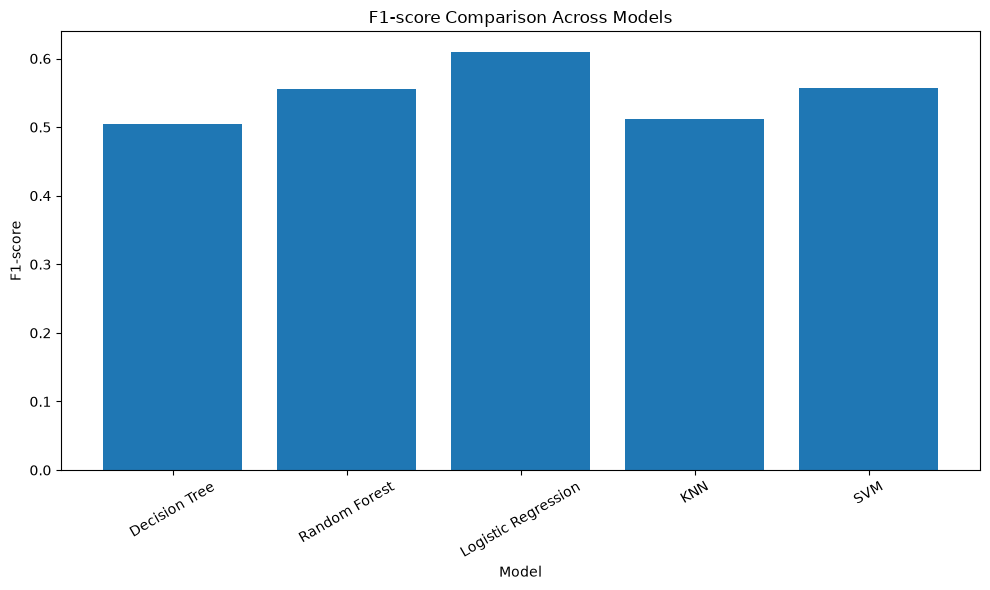

In [27]:
# F1-score bar chart

plt.figure(figsize=(10, 6))

plt.bar(
    model_comparison["Model"],
    model_comparison["F1-score"]
)

plt.ylabel("F1-score")
plt.xlabel("Model")
plt.title("F1-score Comparison Across Models")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### Part 6 — Interpretation

**(a) F1 and recall:**  
Identify the model with the highest measured F1-score and the model with the highest measured recall. State whether they are the same.

**(b) Computational cost:**  
Compare the measured SVM performance with the other models and discuss whether the extra computation is justified for this dataset/use case.

**(c) Final model:**  
Choose one model for deployment using at least **two metrics**, not accuracy alone. Explain the decision using the actual values in your scoreboard.

# Part 7 — Final Predictions and Wrap-Up

## Task 7.1

Generate:
- True label
- Predicted label
- Predicted churn probability/score

and save them as:

`svm_predictions.csv`

Then complete the Executive Summary and Final Reflection.

In [28]:
# =========================
# PART 7 — FINAL MODEL
# =========================

# Set the final model here after considering Parts 5 and 6.
#
# Current default:
# balanced probability-enabled SVM.
#
# If you decide to deploy another model, change the variables below.

final_model = svm_balanced_prob

final_predictions = final_model.predict(X_test_s)

final_probabilities = final_model.predict_proba(X_test_s)[:, 1]

predictions_df = pd.DataFrame({
    "True_Label": y_test.values,
    "Predicted_Label": final_predictions,
    "Predicted_Churn_Probability": final_probabilities
})

display(predictions_df.head(10))

,True_Label,Predicted_Label,Predicted_Churn_Probability
0,0,0,0.060593
1,0,1,0.604234
2,0,0,0.040179
3,0,0,0.254836
4,0,0,0.038981
5,0,1,0.611928
6,0,1,0.362082
7,0,0,0.157781
8,0,0,0.058499
9,1,1,0.475096


In [29]:
# Save required CSV

OUTPUT_FILE = "svm_predictions.csv"

predictions_df.to_csv(
    OUTPUT_FILE,
    index=False
)

print(f"Saved: {OUTPUT_FILE}")
print("Rows:", len(predictions_df))

Saved: svm_predictions.csv
Rows: 1409


# Executive Summary


The Telco Customer Churn dataset was prepared and scaled SVMs were evaluated using linear, RBF, and polynomial kernels. In Part 2, the linear kernel had the highest test F1-score: 0.5714.

GridSearchCV selected C = 100 and gamma = 0.01, with a mean cross-validated F1-score of 0.5877. Using the lab’s final balanced, probability-enabled RBF SVM, the test metrics were:

Accuracy	Precision	Recall	F1-score
0.7466	0.5152	0.7701	0.6174
The balanced metrics are from the lab’s comparison table; accuracy is calculated from its test-set class counts.

Using class_weight="balanced" increased recall from 0.5241 to 0.7701 and F1-score from 0.5568 to 0.6174, while precision fell from 0.5939 to 0.5152. In other words, the model catches more actual churners, but more customers it flags will not churn.

I selected the balanced RBF SVM because it achieved a higher F1-score than the Logistic Regression model in the lab (0.6174 vs. 0.6092) and substantially higher recall (0.7701 vs. 0.5668). That trade-off is useful when missing a potential churner is costly, though its accuracy is lower.

Limitation: The evaluation uses one stratified train/test split, so results may vary with a different split and would benefit from external validation.

